# 911 Calls Project

For this project we will be analyzing some 911 call data from [Kaggle](https://www.kaggle.com/mchirico/montcoalert). The data contains the following fields:

* lat : String variable, Latitude
* lng: String variable, Longitude
* desc: String variable, Description of the Emergency Call
* zip: String variable, Zipcode
* title: String variable, Title
* timeStamp: String variable, YYYY-MM-DD HH:MM:SS
* twp: String variable, Township
* addr: String variable, Address
* e: String variable, Dummy variable (always 1)

Just go along with this notebook and try to complete the instructions or answer the questions in bold using your Python and Data Science skills!

## Data and Setup

___
**Import numpy and pandas**

In [1]:
import numpy as np
import pandas as pd

** Import visualization libraries and set %matplotlib inline. **

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')


** Read in the csv file as a dataframe called df **

In [3]:
df = pd.read_csv('911.csv')

** Check the info() of the df **

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  str    
 3   zip        86637 non-null  float64
 4   title      99492 non-null  str    
 5   timeStamp  99492 non-null  str    
 6   twp        99449 non-null  str    
 7   addr       98973 non-null  str    
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 6.8 MB


** Check the head of df **

In [5]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


## Basic Questions

** What are the top 5 zipcodes for 911 calls? **

In [6]:
df['zip'].value_counts().head()


zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

** What are the top 5 townships (twp) for 911 calls? **

In [7]:
df['twp'].value_counts().head()


twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

** Take a look at the 'title' column, how many unique title codes are there? **

In [8]:
df['title'].nunique()


110

## Creating new features

** In the titles column there are "Reasons/Departments" specified before the title code. These are EMS, Fire, and Traffic. Use .apply() with a custom lambda expression to create a new column called "Reason" that contains this string value.** 

**For example, if the title column value is EMS: BACK PAINS/INJURY , the Reason column value would be EMS. **
Please try to answer the following questions:
** What is the most common Reason for a 911 call based off of this new column? and please visualize them by seaborn**
* What is the data type of the objects in the timeStamp column? 
* If it is not in datetime object use pd.to_datetime to convert the column to DateTime objects.
* Make new feature include Hour, Month, and Day of Week=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'].
* **Now use seaborn to create a countplot of the Day of Week column with the hue based of the Reason column.**
* do the same for Month.

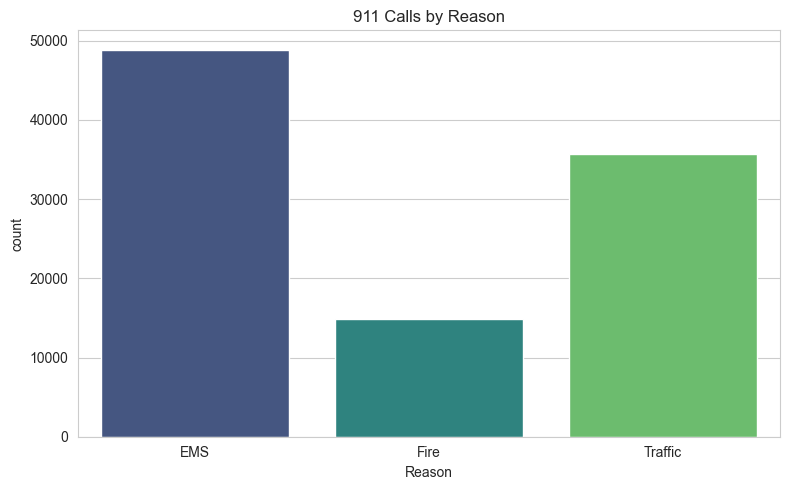

In [ ]:
df['Reason'] = df['title'].apply(lambda title: title.split(':')[0])
df['Reason'].value_counts()

plt.figure(figsize=(8, 5))
sns.countplot(x='Reason', data=df, hue='Reason', palette='viridis', legend=False)
plt.title('911 calls by reason')
plt.tight_layout()


In [10]:
df['timeStamp'].dtype
df['timeStamp'] = pd.to_datetime(df['timeStamp'])
df['timeStamp'].dtype


dtype('<M8[us]')

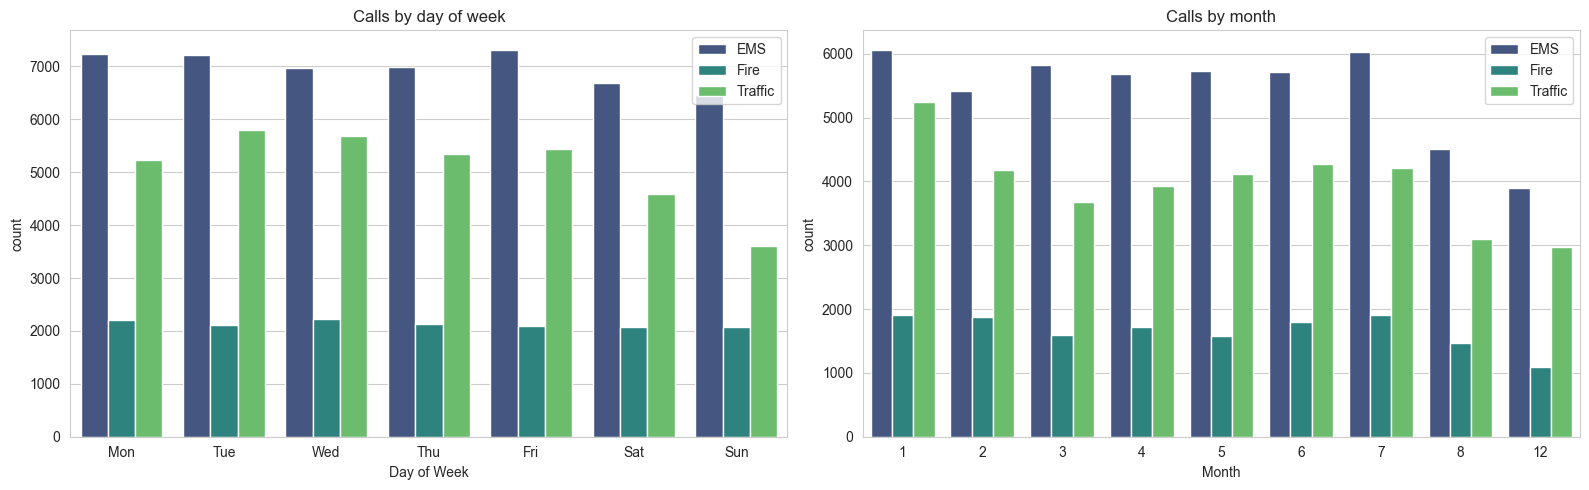

In [ ]:
df['Hour'] = df['timeStamp'].apply(lambda time: time.hour)
df['Month'] = df['timeStamp'].apply(lambda time: time.month)
df['Day of Week'] = df['timeStamp'].apply(lambda time: time.dayofweek)

dmap = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['Day of Week'] = df['Day of Week'].map(dmap)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(x='Day of Week', data=df, hue='Reason', order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], ax=axes[0], palette='viridis')
axes[0].set_title('Calls by Day of Week')
axes[0].legend(loc='upper right')

sns.countplot(x='Month', data=df, hue='Reason', ax=axes[1], palette='viridis')
axes[1].set_title('Calls by Month')
axes[1].legend(loc='upper right')

plt.tight_layout()


If you do all steps correctly we expected to see the following resutls for the last question 

In [12]:
sorted(df['Month'].unique())


[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(12)]

**Did you notice something strange about the Plot?**

_____



In [13]:
print('Missing months in the plot:', sorted(set(range(1, 13)) - set(df['Month'].unique())))


Missing months in the plot: [9, 10, 11]


**You should have noticed it was missing some Months, let's see if we can maybe fill in this information by plotting the information in another way, possibly a simple line plot that fills in the missing months, in order to do this, we'll need to do some work with pandas...**

** Now create a gropuby object called byMonth, where you group the DataFrame by the month column and use the count() method for aggregation. Use the head() method on this returned DataFrame. **

In [14]:
byMonth = df.groupby('Month').count()
byMonth.head()


,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Day of Week
Month,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,13205
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,11467
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,11101
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,11326
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,11423


** Now create a simple plot off of the dataframe indicating the count of calls per month. **

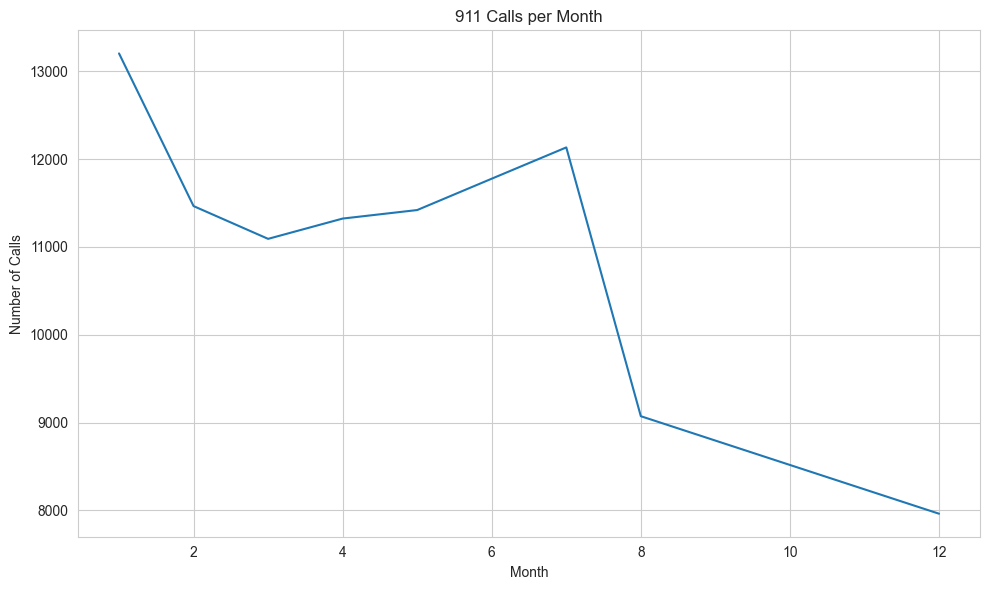

In [ ]:
byMonth['twp'].plot(figsize=(10, 6))
plt.title('911 calls per month')
plt.ylabel('Number of calls')
plt.tight_layout()


** Now see if you can use seaborn's lmplot() to create a linear fit on the number of calls per month. Keep in mind you may need to reset the index to a column. **

Text(0.5, 1.0, 'Monthly call trend')

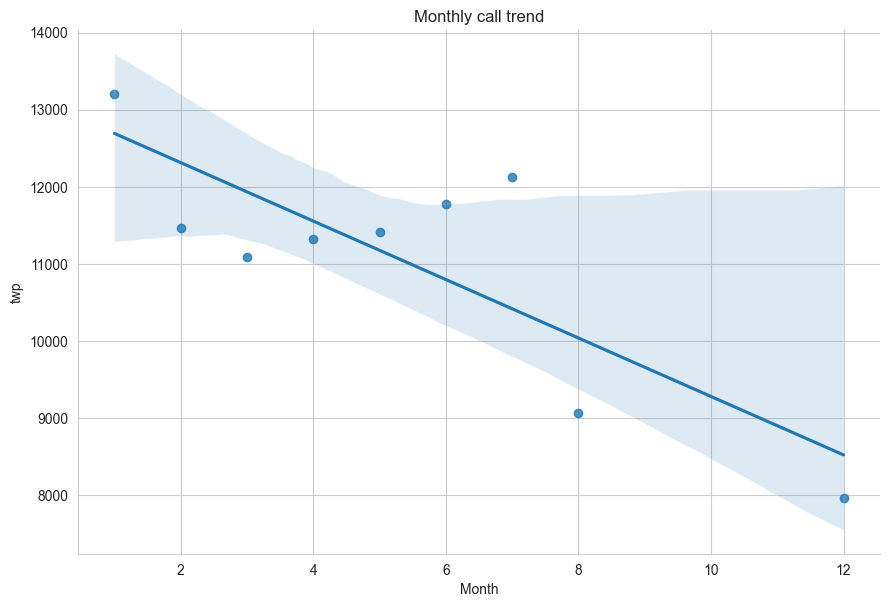

In [29]:
sns.lmplot(x='Month', y='twp', data=byMonth.reset_index(), height=6, aspect=1.5)
plt.title('Monthly call trend')


**Create a new column called 'Date' that contains the date from the timeStamp column. You'll need to use apply along with the .date() method. ** 

In [17]:
df['Date'] = df['timeStamp'].apply(lambda t: t.date())
df[['timeStamp', 'Date']].head()


,timeStamp,Date
0,2015-12-10 17:40:00,2015-12-10
1,2015-12-10 17:40:00,2015-12-10
2,2015-12-10 17:40:00,2015-12-10
3,2015-12-10 17:40:01,2015-12-10
4,2015-12-10 17:40:01,2015-12-10


** Now groupby this Date column with the count() aggregate and create a plot of counts of 911 calls.**

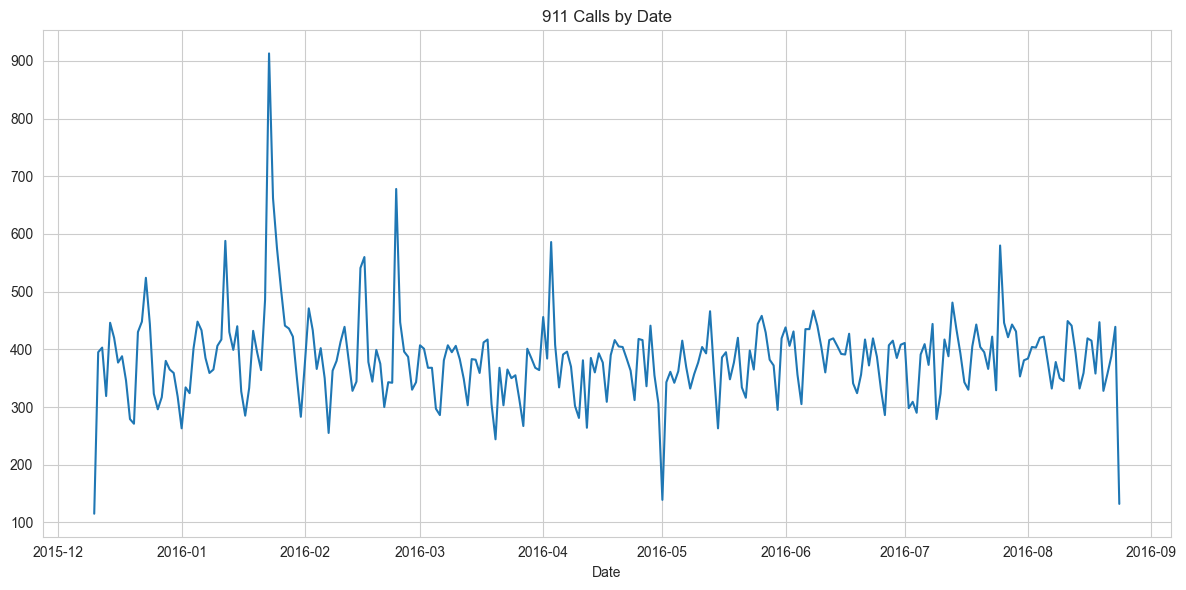

In [ ]:
df.groupby('Date').count()['twp'].plot(figsize=(12, 6))
plt.title('911 calls by date')
plt.tight_layout()


** Now recreate this plot but create 3 separate plots with each plot representing a Reason for the 911 call**

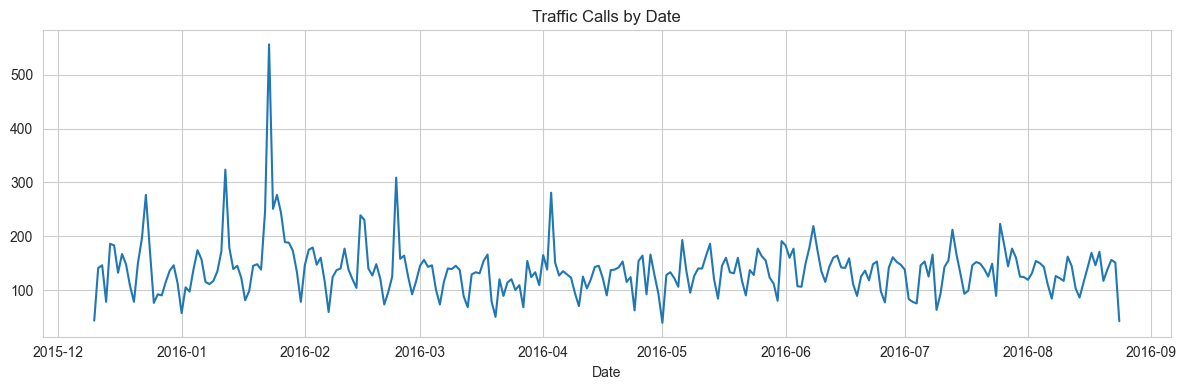

In [ ]:
df[df['Reason'] == 'Traffic'].groupby('Date').count()['twp'].plot(figsize=(12, 4))
plt.title('Traffic calls by date')
plt.tight_layout()


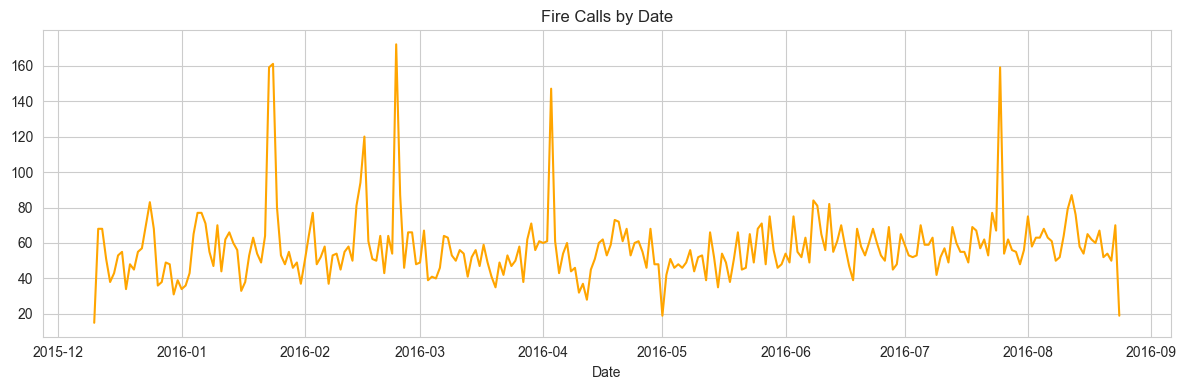

In [ ]:
df[df['Reason'] == 'Fire'].groupby('Date').count()['twp'].plot(figsize=(12, 4), color='orange')
plt.title('Fire calls by date')
plt.tight_layout()


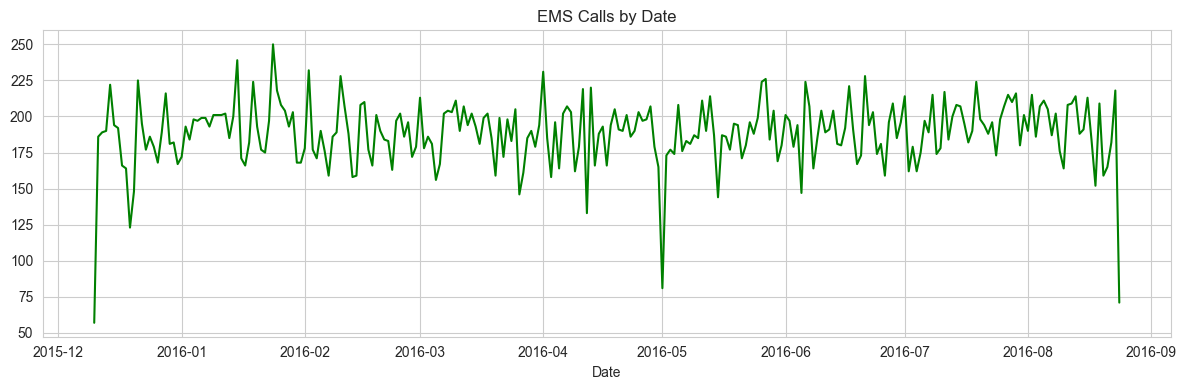

In [ ]:
df[df['Reason'] == 'EMS'].groupby('Date').count()['twp'].plot(figsize=(12, 4), color='green')
plt.title('EMS calls by date')
plt.tight_layout()


____
** Now let's move on to creating  heatmaps with seaborn and our data. We'll first need to restructure the dataframe so that the columns become the Hours and the Index becomes the Day of the Week. There are lots of ways to do this, but I would recommend trying to combine groupby with an [unstack](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.unstack.html) method. Reference the solutions if you get stuck on this!**

In [22]:
dayHour = df.groupby(by=['Day of Week', 'Hour']).count()['Reason'].unstack()
dayHour


Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,
Fri,275,235,191,175,201,194,372,598,742,752,...,932,980,1039,980,820,696,667,559,514,474
Mon,282,221,201,194,204,267,397,653,819,786,...,869,913,989,997,885,746,613,497,472,325
Sat,375,301,263,260,224,231,257,391,459,640,...,789,796,848,757,778,696,628,572,506,467
Sun,383,306,286,268,242,240,300,402,483,620,...,684,691,663,714,670,655,537,461,415,330
Thu,278,202,233,159,182,203,362,570,777,828,...,876,969,935,1013,810,698,617,553,424,354
Tue,269,240,186,170,209,239,415,655,889,880,...,943,938,1026,1019,905,731,647,571,462,274
Wed,250,216,189,209,156,255,410,701,875,808,...,904,867,990,1037,894,686,668,575,490,335


** Now create a HeatMap using this new DataFrame. **

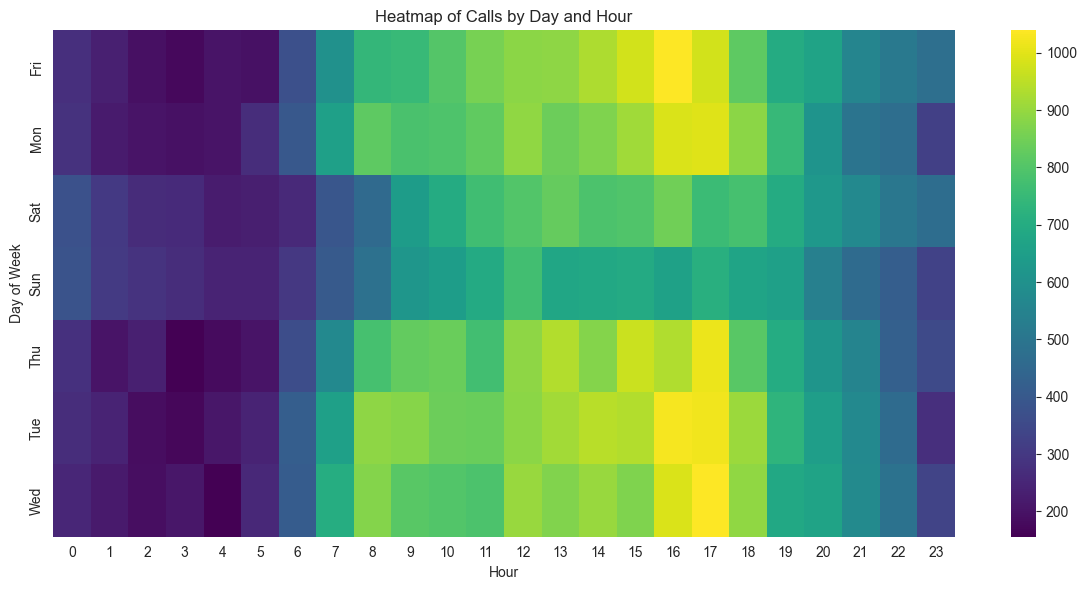

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(dayHour, cmap='viridis')
plt.title('Heatmap of calls by day and hour')
plt.tight_layout()


** Now create a clustermap using this DataFrame. **

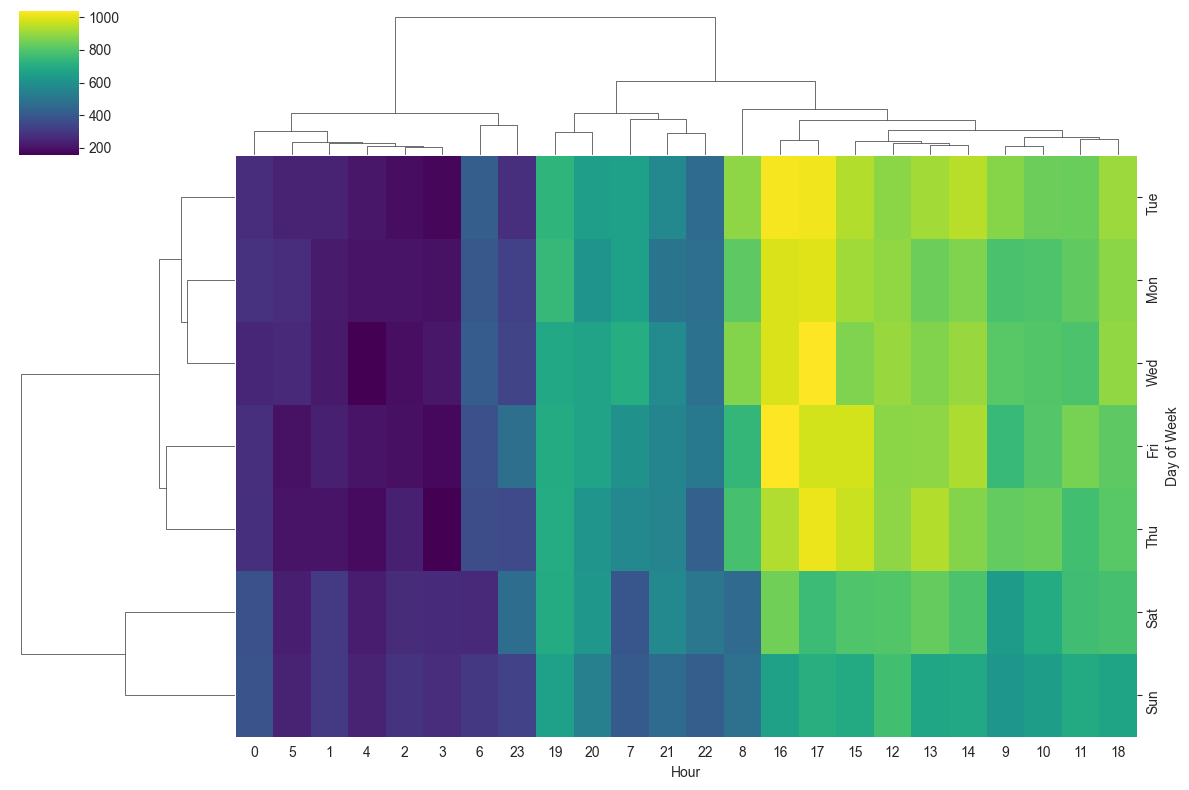

In [24]:
try:
    sns.clustermap(dayHour, cmap='viridis', figsize=(12, 8))
except RuntimeError as err:
    print(f'Could not create clustermap: {err}')


** Now repeat these same plots and operations, for a DataFrame that shows the Month as the column. **

In [25]:
dayMonth = df.groupby(by=['Day of Week', 'Month']).count()['Reason'].unstack()
dayMonth


Month,1,2,3,4,5,6,7,8,12
Day of Week,,,,,,,,,
Fri,1970,1581,1525,1958,1730,1649,2045,1310,1065
Mon,1727,1964,1535,1598,1779,1617,1692,1511,1257
Sat,2291,1441,1266,1734,1444,1388,1695,1099,978
Sun,1960,1229,1102,1488,1424,1333,1672,1021,907
Thu,1584,1596,1900,1601,1590,2065,1646,1230,1266
Tue,1973,1753,1884,1430,1918,1676,1670,1612,1234
Wed,1700,1903,1889,1517,1538,2058,1717,1295,1262


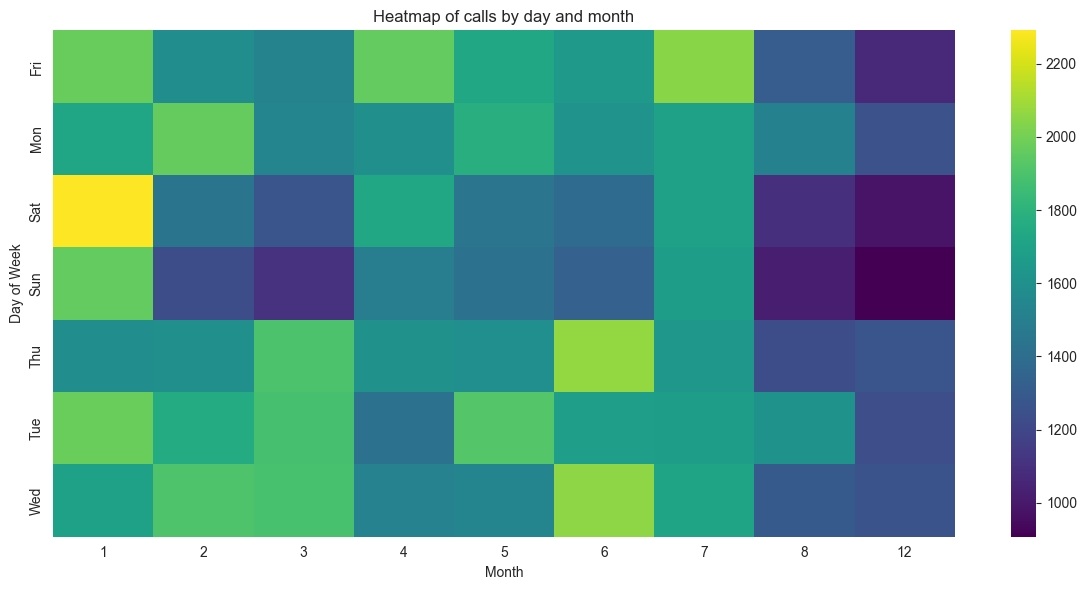

In [30]:
plt.figure(figsize=(12, 6))
sns.heatmap(dayMonth, cmap='viridis')
plt.title('Heatmap of calls by day and month')
plt.tight_layout()


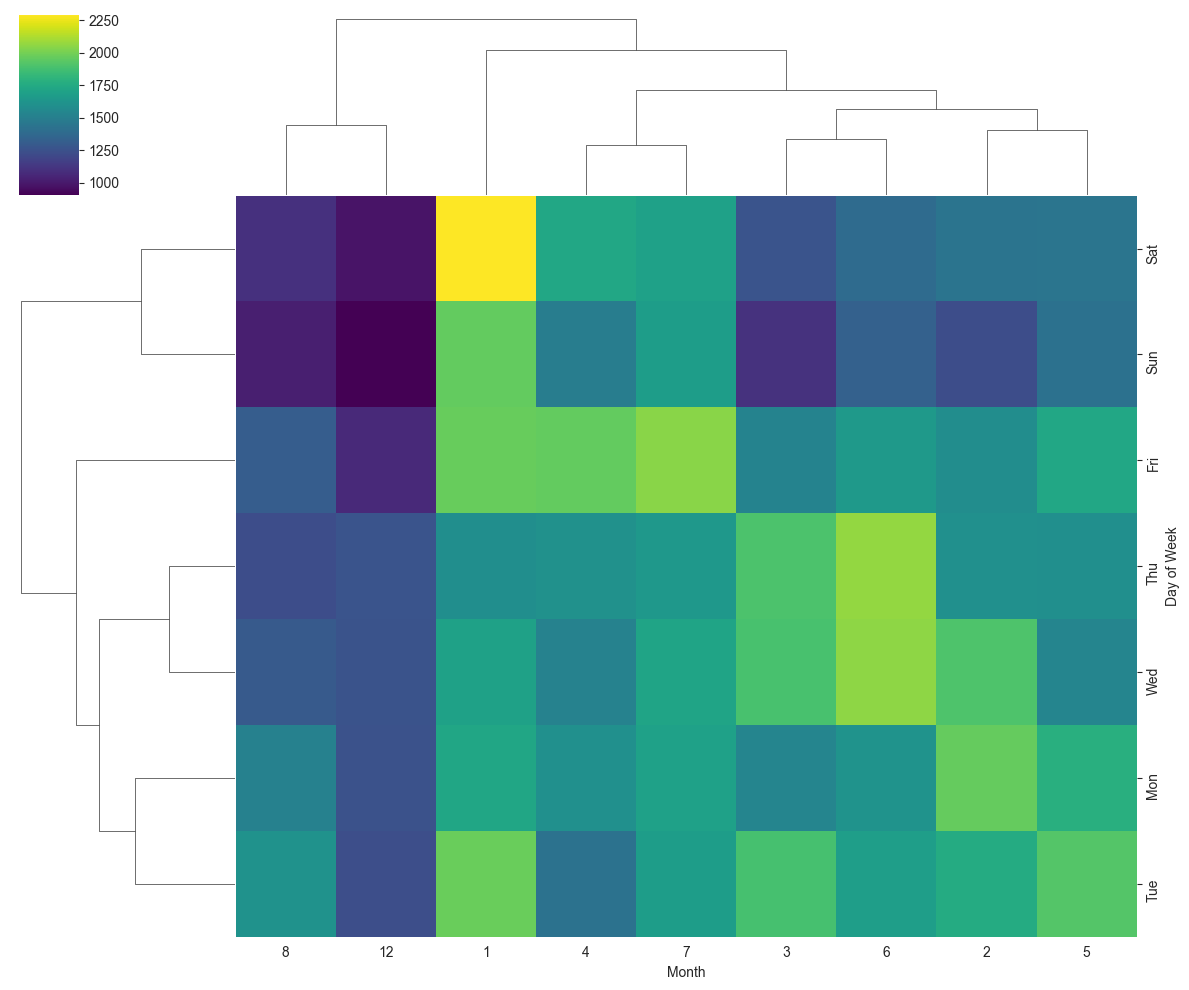

In [35]:
sns.clustermap(dayMonth, cmap='viridis', figsize=(12, 10))


**Continue exploring the Data however you see fit!**
# Great Job!